Part 1: Data Processing

In [10]:
import re
import csv
import nltk
from pathlib import Path
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

csv.field_size_limit(2**31-1)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\b(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:t(?:ember)?)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)(?!\.\w)(?:\.(?=\s|$|\d))?(?:\s+(?:0?[1-9]|[12][0-9]|3[01])(?:\s*,?\s*(?:\d{2}|\d{4}))?)?(?=\W|$)", "<DATE>", text)
    text = re.sub(r"\b\d+(?:[.,]\d+)?\b", "<NUM>", text)
    text = re.sub(r"https?://\S+", "<URL>", text)
    text = re.sub(r"www\.\S+", "<URL>", text)
    text = re.sub(r"\S+\.com\S*", "<URL>", text)
    return re.sub(r"\s+", " ", text).strip()

tokenizer = RegexpTokenizer(r"<URL>|<NUM>|<DATE>|[a-z]+(?:'[a-z]+)?")

def tokenize_nltk(cleaned_text: str):
    return tokenizer.tokenize(cleaned_text)

try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    STOPWORDS = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS]

stemmer = SnowballStemmer("english")

def stem_tokens(tokens):
    out = []
    for t in tokens:
        if t in ("<URL>", "<NUM>", "<DATE>"):
            out.append(t)
        else:
            out.append(stemmer.stem(t))
    return out

def reduction_rate(before, after):
    if before == 0:
        return 0.0
    return (before - after) / before

file_path = Path("Data") / "995,000_rows.csv"
out_path = file_path.with_name("processed_" + file_path.name)
out_path.parent.mkdir(parents=True, exist_ok=True)
limit_rows = None 

print("Using file:", file_path)
if not file_path.exists():
    raise FileNotFoundError(f"Kan ikke finde filen: {file_path}")

vocab_raw, vocab_no_stop, vocab_stemmed = set(), set(), set()
total_raw, total_no_stop, docs_read = 0, 0, 0

with open(file_path, "r", encoding="utf-8-sig", newline="") as f_in, \
     open(out_path, "w", encoding="utf-8", newline="") as f_out:
    reader = csv.DictReader(f_in)
    writer = csv.DictWriter(f_out, fieldnames=["type", "processed_content"])
    writer.writeheader()

    for row in reader:
        if limit_rows is not None and docs_read >= limit_rows:
            break
        docs_read += 1

        raw_content = row.get("content", "") or ""
        cleaned = clean_text(raw_content)
        tokens = tokenize_nltk(cleaned)
        tokens_no_stop = remove_stopwords(tokens)
        tokens_stem = stem_tokens(tokens_no_stop)

        total_raw += len(tokens)
        total_no_stop += len(tokens_no_stop)
        vocab_raw.update(tokens)
        vocab_no_stop.update(tokens_no_stop)
        vocab_stemmed.update(tokens_stem)

        writer.writerow({"type": row.get("type"), "processed_content": " ".join(tokens_stem)})

        if docs_read % 50_000 == 0:
            print(f"Processed {docs_read} documents...")

print(f"Processed data saved to: {out_path}")

V_raw, V_no_stop, V_stem = len(vocab_raw), len(vocab_no_stop), len(vocab_stemmed)
rr_stop = reduction_rate(V_raw, V_no_stop)
rr_stem = reduction_rate(V_no_stop, V_stem)
rr_stem_from_raw = reduction_rate(V_raw, V_stem)
token_rr_stop = (total_raw - total_no_stop) / total_raw if total_raw else 0

print(f"\nSample size (documents): {docs_read:,}")
print(f"Vocabulary size (tokenized): {V_raw:,}")
print(f"Vocabulary size (after stopwords): {V_no_stop:,}")
print(f"Reduction rate (stopwords): {rr_stop:.4f} = {rr_stop*100:.2f}%")
print(f"Vocabulary size (after stemming): {V_stem:,}")
print(f"Reduction rate (stemming): {rr_stem:.4f} = {rr_stem*100:.2f}%")
print(f"Reduction rate (stemming vs raw): {rr_stem_from_raw:.4f} = {rr_stem_from_raw*100:.2f}%")
print(f"Total tokens (raw): {total_raw:,}")
print(f"Total tokens (after stopwords): {total_no_stop:,}")
print(f"Token reduction (stopwords): {token_rr_stop:.4f} = {token_rr_stop*100:.2f}%")

Using file: Data/995,000_rows.csv
Processed 50000 documents...
Processed 100000 documents...
Processed 150000 documents...
Processed 200000 documents...
Processed 250000 documents...
Processed 300000 documents...
Processed 350000 documents...
Processed 400000 documents...
Processed 450000 documents...
Processed 500000 documents...
Processed 550000 documents...
Processed 600000 documents...
Processed 650000 documents...
Processed 700000 documents...
Processed 750000 documents...
Processed 800000 documents...
Processed 850000 documents...
Processed 900000 documents...
Processed 950000 documents...
Processed data saved to: Data/processed_995,000_rows.csv

Sample size (documents): 995,000
Vocabulary size (tokenized): 1,004,633
Vocabulary size (after stopwords): 1,004,435
Reduction rate (stopwords): 0.0002 = 0.02%
Vocabulary size (after stemming): 794,443
Reduction rate (stemming): 0.2091 = 20.91%
Reduction rate (stemming vs raw): 0.2092 = 20.92%
Total tokens (raw): 468,089,820
Total tokens

Task 2: Data Preprocessing (995K words)

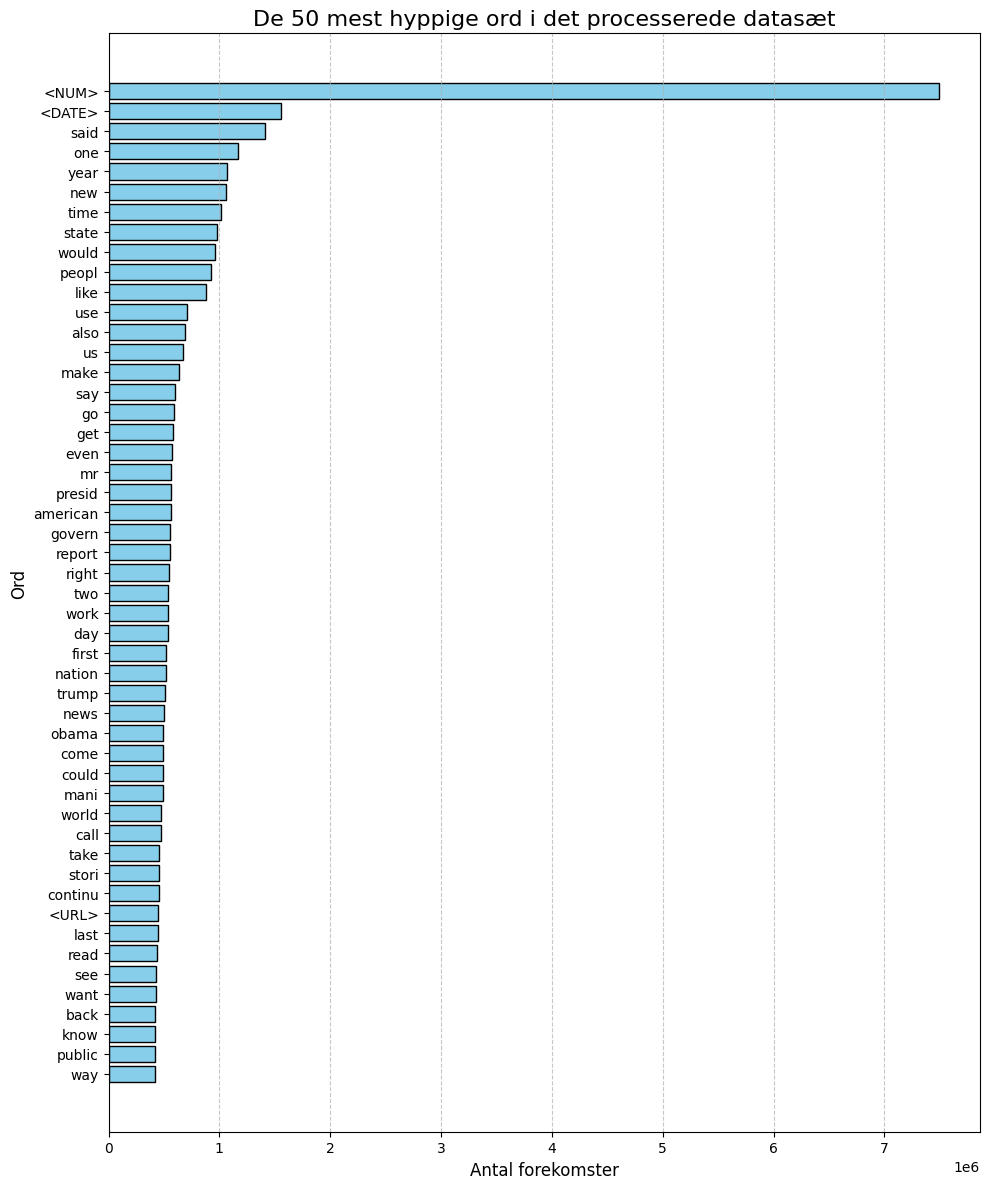

In [11]:
from collections import Counter
import csv
import matplotlib.pyplot as plt

freq = Counter()
with open("data/processed_995,000_rows.csv", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        content = row.get("processed_content", "")
        if content:
            freq.update(content.split())

top_50 = freq.most_common(50)

top_50.reverse()
words = [item[0] for item in top_50]
counts = [item[1] for item in top_50]

# Visualisering med matplotlib:
plt.figure(figsize=(10, 12))
plt.barh(words, counts, color='skyblue', edgecolor='black')

plt.title("De 50 mest hyppige ord i det processerede datasæt", fontsize=16)
plt.xlabel("Antal forekomster", fontsize=12)
plt.ylabel("Ord", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Task 4: Splitting the data set:

In [13]:
import csv
import random
from pathlib import Path
from collections import Counter

def compute_targets(label_counts: Counter, train=0.8, val=0.1, test=0.1):
    targets = {}
    for label, n in label_counts.items():
        n_train = int(round(n * train))
        n_val = int(round(n * val))
        n_test = n - n_train - n_val
        targets[label] = {"train": n_train, "val": n_val, "test": n_test}
    return targets

def choose_split(remaining: dict, rng: random.Random):
    total = remaining["train"] + remaining["val"] + remaining["test"]
    if total <= 0:
        return None
    r = rng.randrange(total)
    if r < remaining["train"]:
        return "train"
    r -= remaining["train"]
    if r < remaining["val"]:
        return "val"
    return "test"

def main():
    in_path = Path("Data") / "processed_995,000_rows.csv"
    seed = 42
    out_dir = in_path.parent / "splits"
    out_dir.mkdir(parents=True, exist_ok=True)

    train_path = out_dir / "train.csv"
    val_path = out_dir / "val.csv"
    test_path = out_dir / "test.csv"

    label_counts = Counter()
    with open(in_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)

        for row in reader:
            label = row["type"]
            label_counts[label] += 1

    targets = compute_targets(label_counts, train=0.8, val=0.1, test=0.1)

    print("Label counts:", dict(label_counts))
    print("Targets per label:", targets)

    rng = random.Random(seed)

    with open(in_path, "r", encoding="utf-8", newline="") as f_in, \
         open(train_path, "w", encoding="utf-8", newline="") as f_train, \
         open(val_path, "w", encoding="utf-8", newline="") as f_val, \
         open(test_path, "w", encoding="utf-8", newline="") as f_test:

        reader = csv.DictReader(f_in)
        fieldnames = reader.fieldnames

        w_train = csv.DictWriter(f_train, fieldnames=fieldnames)
        w_val = csv.DictWriter(f_val, fieldnames=fieldnames)
        w_test = csv.DictWriter(f_test, fieldnames=fieldnames)

        w_train.writeheader()
        w_val.writeheader()
        w_test.writeheader()

        written = Counter()

        for row in reader:
            label = row["type"]
            remaining = targets[label]

            split = choose_split(remaining, rng)
            if split is None:
                split = "train"

            if split == "train":
                w_train.writerow(row)
            elif split == "val":
                w_val.writerow(row)
            else:
                w_test.writerow(row)

            targets[label][split] -= 1
            written[split] += 1

    print("Wrote:", dict(written))
    print("Output directory:", out_dir)

if __name__ == "__main__":
    main()

Label counts: {'political': 194518, 'fake': 104883, 'satire': 13160, 'reliable': 218564, 'conspiracy': 97314, 'unreliable': 35332, 'bias': 133232, 'rumor': 56445, 'unknown': 43534, '': 47786, 'clickbait': 27412, 'hate': 8779, 'junksci': 14040, '2018-02-10 13:43:39.521661': 1}
Targets per label: {'political': {'train': 155614, 'val': 19452, 'test': 19452}, 'fake': {'train': 83906, 'val': 10488, 'test': 10489}, 'satire': {'train': 10528, 'val': 1316, 'test': 1316}, 'reliable': {'train': 174851, 'val': 21856, 'test': 21857}, 'conspiracy': {'train': 77851, 'val': 9731, 'test': 9732}, 'unreliable': {'train': 28266, 'val': 3533, 'test': 3533}, 'bias': {'train': 106586, 'val': 13323, 'test': 13323}, 'rumor': {'train': 45156, 'val': 5644, 'test': 5645}, 'unknown': {'train': 34827, 'val': 4353, 'test': 4354}, '': {'train': 38229, 'val': 4779, 'test': 4778}, 'clickbait': {'train': 21930, 'val': 2741, 'test': 2741}, 'hate': {'train': 7023, 'val': 878, 'test': 878}, 'junksci': {'train': 11232, 'va